In [23]:
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [2]:
from utils.utils import *
from utils.config import Config

# allocate_dummy_gpu_memory(10)

In [ ]:
cfg = Config(name='Visualization', data='EchoNet-Dynamic')
print(cfg)

RUN_SPLIT = False

----------------------------------------------------------------------
                        Config Details (Auto)                         
----------------------------------------------------------------------

[ Base Settings ]
  name                   : Visualization
  data                   : EchoNet-Dynamic
  mkdir                  : False
  dtype                  : float64
  device                 : cpu
  multi_gpu              : False

[ Paths ]
  base_path              : /ds/mkseo/SM-Dehazing
  data_path              : /ds/mkseo/SM-Dehazing/data
  res_path               : /ds/mkseo/SM-Dehazing/res/Visualization
  fig_path               : /ds/mkseo/SM-Dehazing/res/Visualization/fig
  loss_path              : /ds/mkseo/SM-Dehazing/res/Visualization/loss
  model_path             : /ds/mkseo/SM-Dehazing/res/Visualization/model
----------------------------------------------------------------------


#### *Train/Valid/Test Split*

In [ ]:
if RUN_SPLIT:
    FRC_ROOT = Path('/ds/mkseo/SM-Dehazing/data/EchoNet-Dynamic/haze_deblur')
    SRC_ROOT = Path('/ds/mkseo/SM-Dehazing/data/EchoNet-Dynamic')

    NOISE_TYPE = ['haze', 'speckle', 'sumation_speckle']
    SPLITS = ['train', 'valid', 'test']
    SUBDIRS = ['clean', 'noisy', 'noise']

    # 파일 이름은 clean 기준으로만 가져옴
    SPLIT_DICT = {
        split: sorted([
            f.name for f in (FRC_ROOT / split / 'clean').iterdir()
            if f.is_file()
        ])
        for split in SPLITS
    }
    for split, f_list in SPLIT_DICT.items():
        print(f'{split}: {len(f_list)} files')

    for noise_type in NOISE_TYPE:
        for split, f_list in SPLIT_DICT.items():
            for subdir in SUBDIRS:
                src_dir = SRC_ROOT / noise_type / subdir
                dst_dir = SRC_ROOT / noise_type / split / subdir

                dst_dir.mkdir(parents=True, exist_ok=True)

                copied = 0
                missing = 0

                for fname in f_list:
                    src = src_dir / fname
                    dst = dst_dir / fname

                    if src.exists():
                        shutil.copy2(src, dst)
                        copied += 1
                    else:
                        print(f'[Missing] {src}')
                        missing += 1

                print(f'{noise_type}/{split}/{subdir}: copied={copied}, missing={missing}')

train: 2457 files
valid: 307 files
test: 308 files
haze/train/clean: copied=2457, missing=0
haze/train/noisy: copied=2457, missing=0
haze/train/noise: copied=2457, missing=0
haze/valid/clean: copied=307, missing=0
haze/valid/noisy: copied=307, missing=0
haze/valid/noise: copied=307, missing=0
haze/test/clean: copied=308, missing=0
haze/test/noisy: copied=308, missing=0
haze/test/noise: copied=308, missing=0
speckle/train/clean: copied=2457, missing=0
speckle/train/noisy: copied=2457, missing=0
speckle/train/noise: copied=2457, missing=0
speckle/valid/clean: copied=307, missing=0
speckle/valid/noisy: copied=307, missing=0
speckle/valid/noise: copied=307, missing=0
speckle/test/clean: copied=308, missing=0
speckle/test/noisy: copied=308, missing=0
speckle/test/noise: copied=308, missing=0
sumation_speckle/train/clean: copied=2457, missing=0
sumation_speckle/train/noisy: copied=2457, missing=0
sumation_speckle/train/noise: copied=2457, missing=0
sumation_speckle/valid/clean: copied=307, m

#### *Visualization*

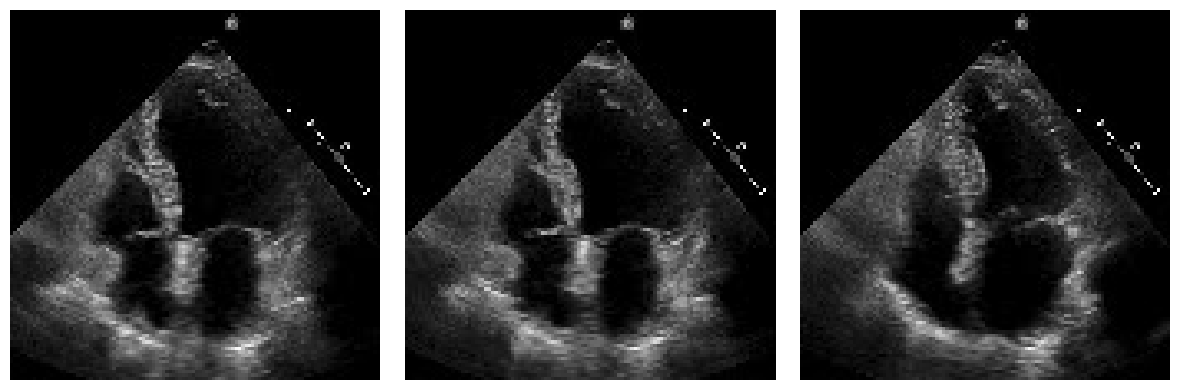

In [14]:
BASE_DIR    = Path(cfg.data_path / 'data_raw' / cfg.data)
FRAME_DIR   = BASE_DIR / 'frames'
FRAME_LIST  = sorted([f.name for f in FRAME_DIR.iterdir()])


metainfo = pd.read_csv(BASE_DIR / 'metainfo.csv')
study_id = metainfo.loc[metainfo['Ori_ID'].eq(target_id:='0X1B05B56F239276F3'), 'Study_ID'].iloc[0]

frames = [f for f in FRAME_LIST if study_id in f]

imgs = [
    cv2.imread(FRAME_DIR / f, 0)
    for f in frames
]

plt.figure(figsize=(12, 4))
for i, img in enumerate(imgs):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(img, cmap='gray')

    plt.axis('off')
plt.tight_layout()
plt.savefig('/workspace/echo_frames.png', dpi=400)
plt.show()

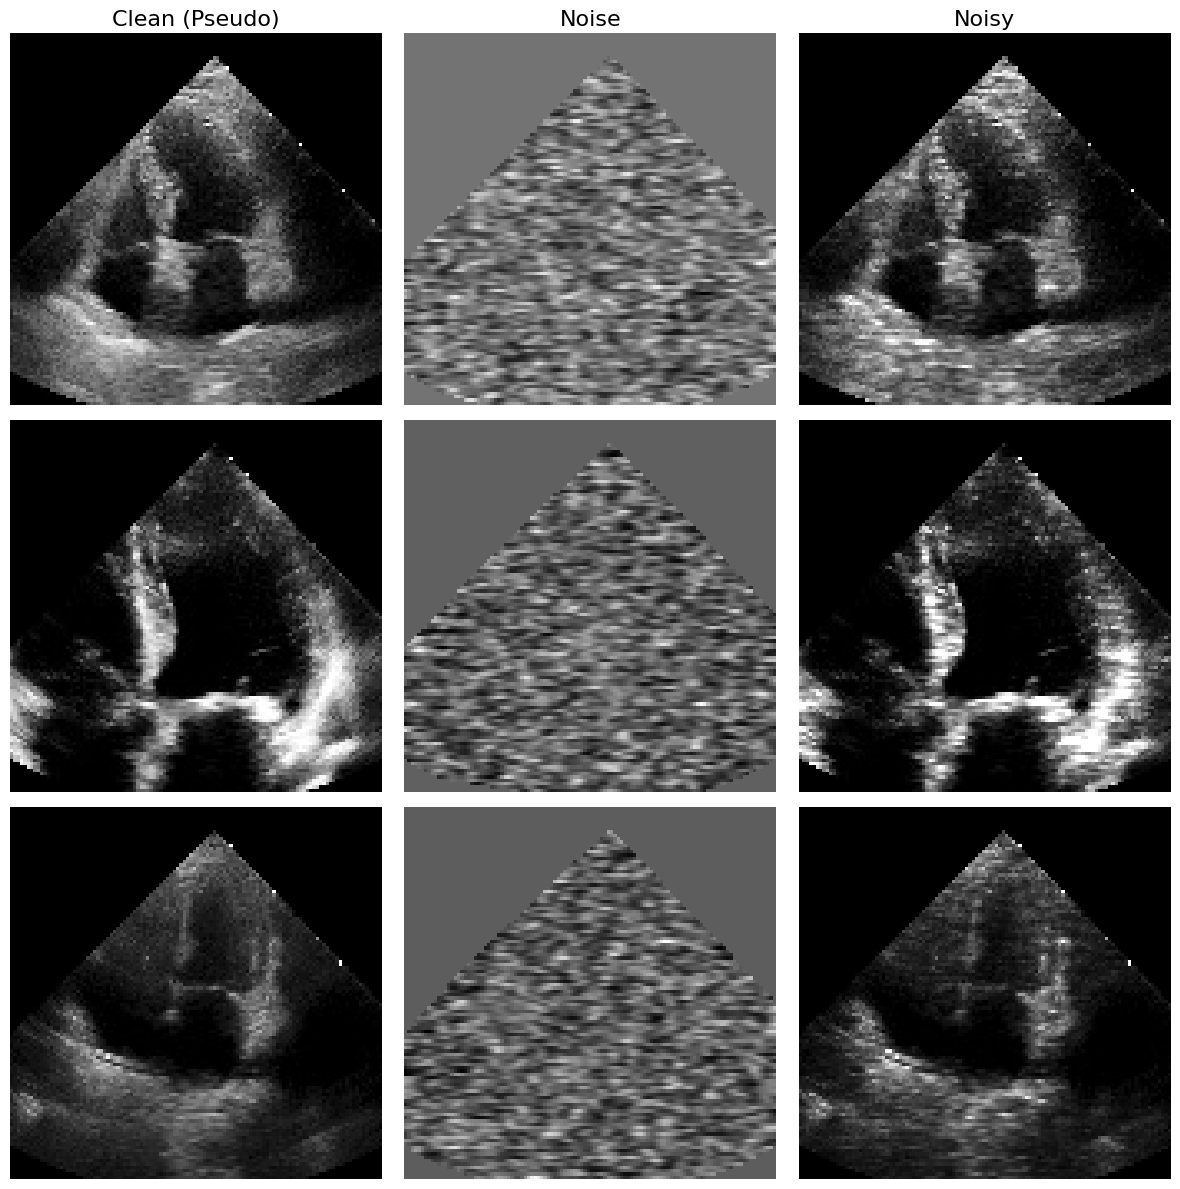

In [43]:
SPECKLE_DIR = Path(cfg.data_path / cfg.data / 'speckle' / 'train')
clean = sorted([f for f in Path(SPECKLE_DIR / 'clean').iterdir()])
noisy = sorted([f for f in Path(SPECKLE_DIR / 'noisy').iterdir()])
noise = sorted([f for f in Path(SPECKLE_DIR / 'noise').iterdir()])

clean_imgs = [tiff.imread(clean[idx]) for idx in [0, 20, 50]]
noisy_imgs = [tiff.imread(noisy[idx]) for idx in [0, 20, 50]]
noise_imgs = [tiff.imread(noise[idx]) for idx in [0, 20, 50]]
imgs = [img for triplet in zip(clean_imgs, noise_imgs, noisy_imgs) for img in triplet]
titles = ['Clean (Pseudo)', 'Noise', 'Noisy']

plt.figure(figsize=(12, 12))
for i, img in enumerate(imgs):
    plt.subplot(3, len(imgs)//3, i+1)
    plt.imshow(img, cmap='gray')
    if i < 3: plt.title(titles[i], fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/workspace/speckle.png', dpi=400)
plt.show()

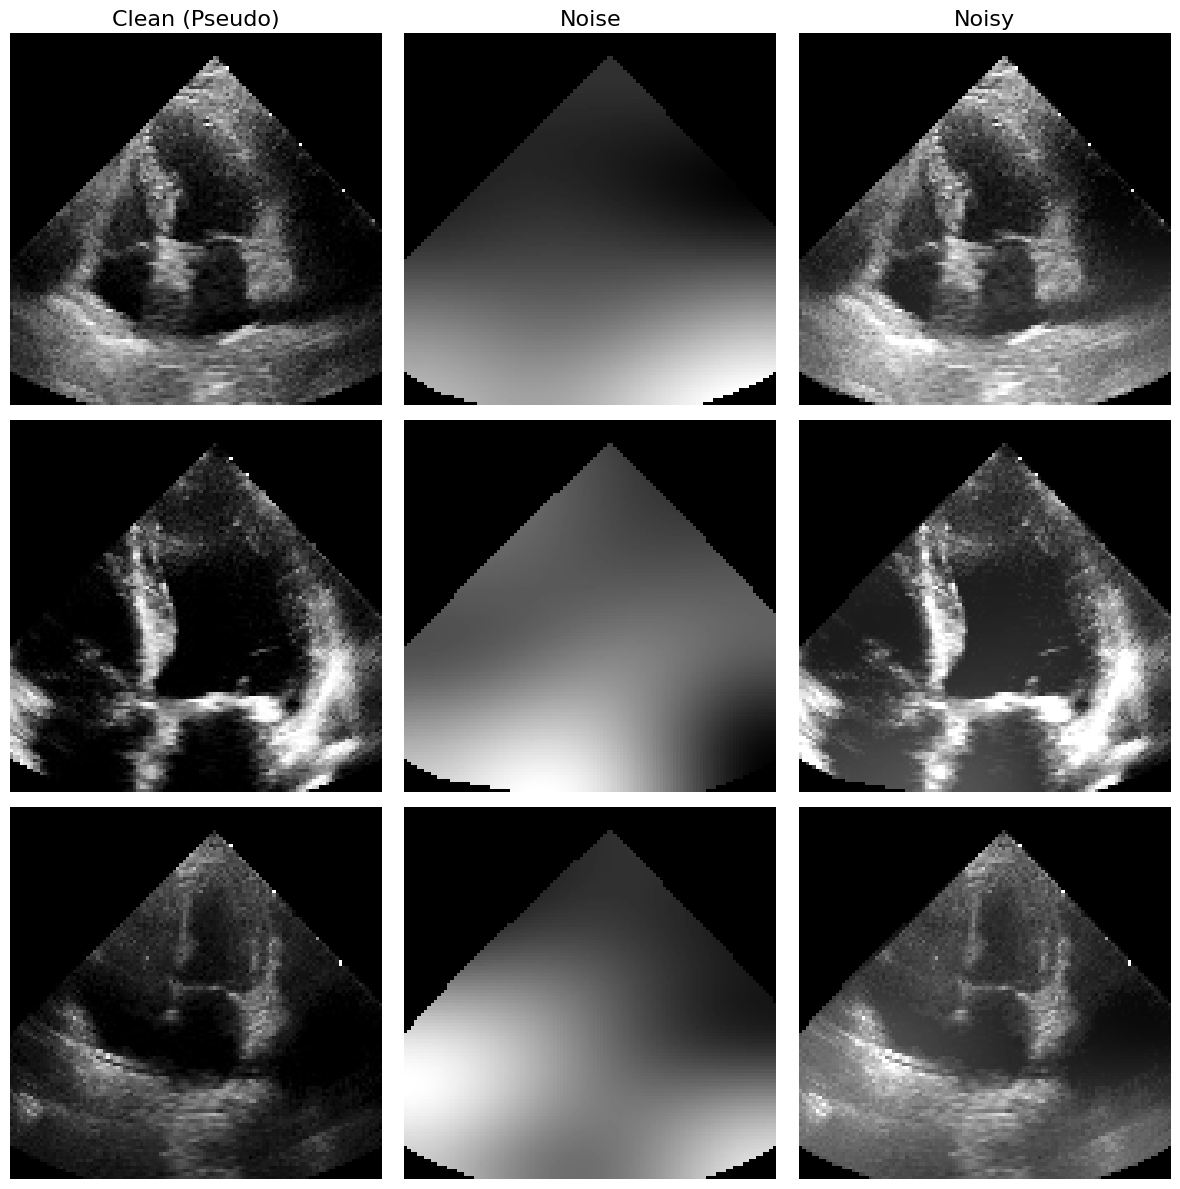

In [46]:
HAZE_DIR = Path(cfg.data_path / cfg.data / 'haze' / 'train')
clean = sorted([f for f in Path(HAZE_DIR / 'clean').iterdir()])
noisy = sorted([f for f in Path(HAZE_DIR / 'noisy').iterdir()])
noise = sorted([f for f in Path(HAZE_DIR / 'noise').iterdir()])

clean_imgs = [tiff.imread(clean[idx]) for idx in [0, 20, 50]]
noisy_imgs = [tiff.imread(noisy[idx]) for idx in [0, 20, 50]]
noise_imgs = [tiff.imread(noise[idx]) for idx in [0, 20, 50]]
imgs = [img for triplet in zip(clean_imgs, noise_imgs, noisy_imgs) for img in triplet]
titles = ['Clean (Pseudo)', 'Noise', 'Noisy']

plt.figure(figsize=(12, 12))
for i, img in enumerate(imgs):
    plt.subplot(3, len(imgs)//3, i+1)
    plt.imshow(img, cmap='gray')
    if i < 3: plt.title(titles[i], fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/workspace/haze.png', dpi=400)
plt.show()

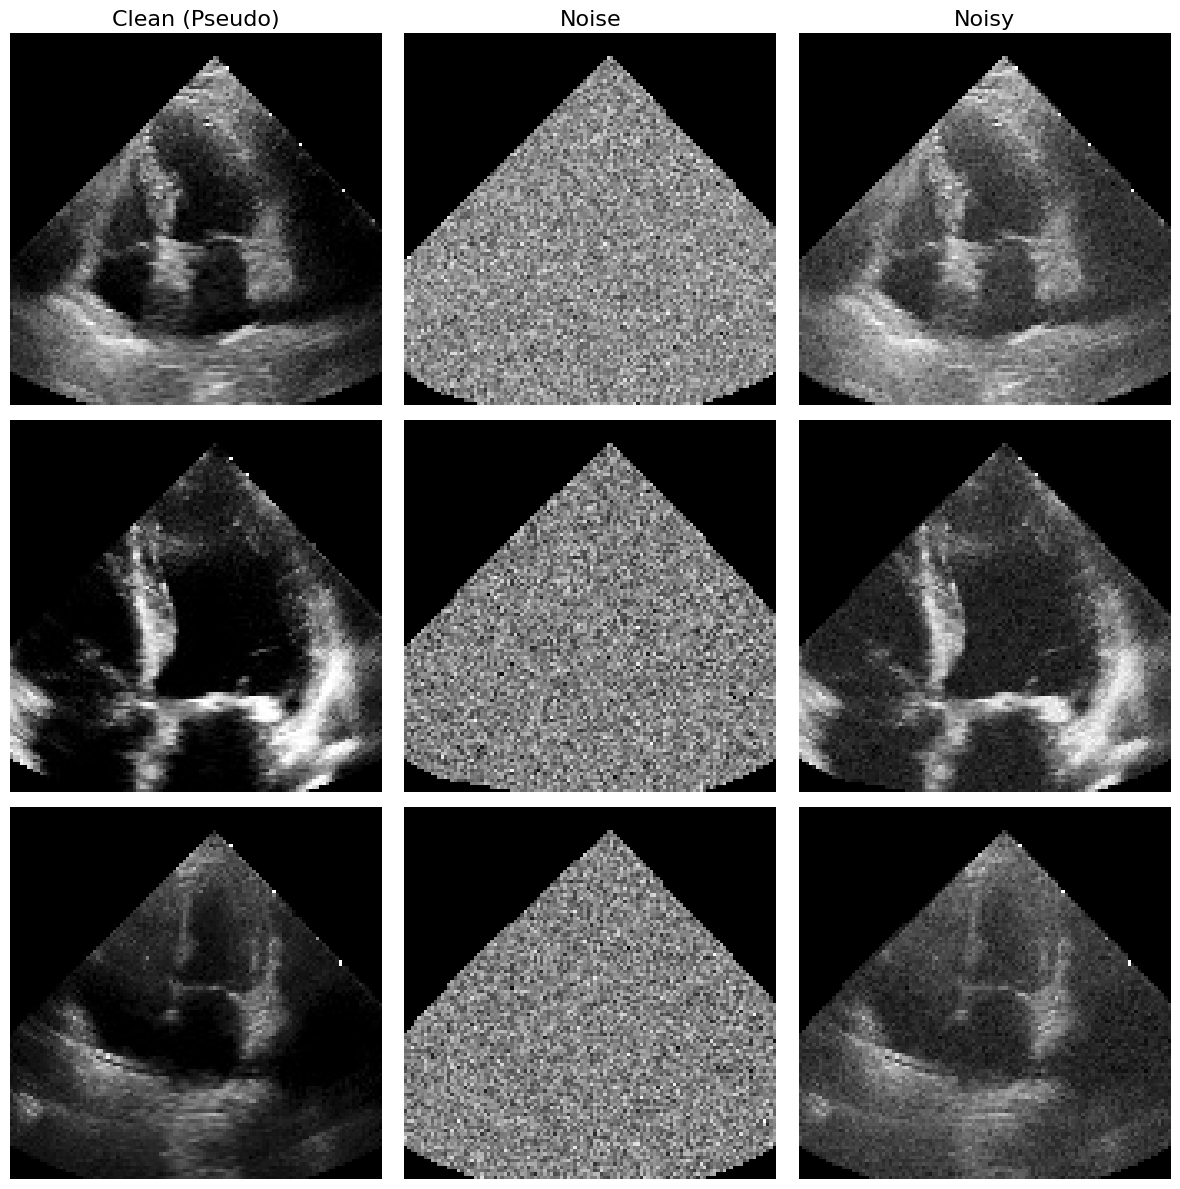

In [47]:
HAZE_DEBLUR_DIR = Path(cfg.data_path / cfg.data / 'haze_deblur' / 'train')
clean = sorted([f for f in Path(HAZE_DEBLUR_DIR / 'clean').iterdir()])
noisy = sorted([f for f in Path(HAZE_DEBLUR_DIR / 'noisy').iterdir()])
noise = sorted([f for f in Path(HAZE_DEBLUR_DIR / 'noise').iterdir()])

clean_imgs = [tiff.imread(clean[idx]) for idx in [0, 20, 50]]
noisy_imgs = [tiff.imread(noisy[idx]) for idx in [0, 20, 50]]
noise_imgs = [tiff.imread(noise[idx]) for idx in [0, 20, 50]]
imgs = [img for triplet in zip(clean_imgs, noise_imgs, noisy_imgs) for img in triplet]
titles = ['Clean (Pseudo)', 'Noise', 'Noisy']

plt.figure(figsize=(12, 12))
for i, img in enumerate(imgs):
    plt.subplot(3, len(imgs)//3, i+1)
    plt.imshow(img, cmap='gray')
    if i < 3: plt.title(titles[i], fontsize=16)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/workspace/haze_deblur.png', dpi=400)
plt.show()